# Attention Residuals 注意力残差聚合实现

## 一、环境导入

In [2]:
import torch  # 导入PyTorch核心库，用于张量操作和自动微分
import torch.nn as nn  # 导入神经网络模块，提供Module/Parameter/Linear等基础组件
import torch.nn.functional as F  # 导入函数式API，提供softmax/silu等无状态函数
import matplotlib.pyplot as plt  # 导入matplotlib绘图库，用于可视化注意力权重分布
from typing import Optional, List  # 导入类型注解：Optional用于可选参数，List用于列表参数

## 二、Full AttnRes 全注意力残差块

In [3]:
class FullAttnResBlock(nn.Module):
    """
    完整注意力残差块（Full Attention Residuals Block）| 对应论文 Section 3.1 Eq.1/2/3

    ★ 设计定位："零件"（可复用的层聚合子模块）
        本类只负责"多个层特征的跨层聚合"，不处理序列，不维护 seq_len 维度。
        输入/输出形状均为 (batch, num_layers, dim)，seq_len 由调用者在外部管理：
          - 调用前：将 (batch, seq_len, dim) reshape → (batch*seq_len, dim)，折叠进 batch
          - 调用后：将结果 reshape 还原为 (batch, seq_len, dim)
        所有 token 位置共享同一套跨层权重，语义等价。

        与 BlockAttnResTransformer（三节，"整机"）的核心区别：
        ┌─────────────────────────────┬────────────────────────────────────────────┐
        │                             │  FullAttnResBlock（二节）  │ BlockAttnResTransformer（三节）│
        ├─────────────────────────────┼────────────────────────────┼────────────────────────────────┤
        │ 设计角色                    │ 零件（子模块）             │ 整机（完整端到端模型）         │
        │ 是否含 seq_len              │ 否（调用者折叠）           │ 是（全程保留，(B,L,S,D)）      │
        │ 注意力方向                  │ 层 → 层（跨层聚合）        │ 层 → 层（每个 token 位置独立） │
        │ seq_len 责任归属            │ 外部调用者                 │ 模型内部                       │
        └─────────────────────────────┴────────────────────────────┴────────────────────────────────┘

    核心思想：
        标准残差连接 h_l = h_{l-1} + F(h_{l-1}) 只利用上一层，
        而 FullAttnResBlock 让每层通过可学习的"伪查询"（pseudo-query）
        对前序所有层的输出做注意力加权聚合，自适应地融合任意历史层信息。

        论文公式：
            scores_l  = (w_l · RMSNorm(H_prev)) / τ    # Equation 2：点积打分
            α_l       = softmax(scores_l)               # 归一化为概率分布
            h_res     = Σ_i  α_{l,i} · H_prev[i]       # Equation 1：加权聚合

    参数:
        dim (int): 隐藏层特征维度，伪查询和前序输出均为该维度。
        num_layers (int): 模型总层数，决定伪查询矩阵 queries 沿第 0 维的大小。

    内部状态:
        self.queries (nn.Parameter): 可学习伪查询矩阵，形状 (num_layers, dim)；
                                     queries[l] 即第 l 层的查询向量 w_l（论文 Equation 3）。
        self.norm (nn.RMSNorm):      对键向量（前序输出）做 RMSNorm 归一化，
                                     稳定不同层输出间的数值范围，防止分数过大/过小。
        self.temperature (nn.Parameter): 可学习温度系数 τ，形状 (1,)，初始值 0.1；
                                          τ 越小注意力分布越均匀，τ 越大越集中到单层。
    """
    def __init__(self, dim: int, num_layers: int):
        """
        初始化 FullAttnResBlock，创建伪查询矩阵、归一化层和温度参数。

        参数:
            dim (int): 特征维度，queries 每行的向量长度。
            num_layers (int): 总层数，queries 共 num_layers 行，每层独立一行。
        """
        super().__init__()  # 调用父类 nn.Module 的初始化方法
        self.dim = dim          # int：特征维度，保存供外部引用
        self.num_layers = num_layers  # int：总层数，与 queries.shape[0] 一致

        # 可学习伪查询矩阵，形状 (num_layers, dim)
        # queries[l] 是第 l 层的向量 w_l，随机初始化，通过反向传播学习
        # 每层独立参数，使不同层可以学会关注不同的历史层组合
        #
        # ★ 为何没有 seq_len 维度？
        #   queries 形状是 (num_layers, dim)，每层只有"一个"全局查询向量，
        #   与序列位置无关——它回答的是"整层应关注哪些历史层"，
        #   而非"某个 token 应关注哪些 token"（那是 Self-Attention 的职责）。
        #   若输入为序列数据 (batch, seq_len, dim)，只需将 seq_len 折叠进 batch：
        #     reshape → (batch*seq_len, dim)，历史层堆叠后 → (batch*seq_len, num_prev, dim)，
        #   每个 token 位置独立共享同一套层级查询权重，语义完全等价。
        self.queries = nn.Parameter(torch.randn(num_layers, dim))  # 可学习伪查询矩阵，形状 (num_layers, dim)，queries[l] 即层 l 的查询向量 w_l

        # 对前序层输出（键向量）做 RMSNorm：消除不同层输出幅度差异，
        # 避免少数激活值大的层在点积中占主导，影响注意力公平性
        self.norm = nn.RMSNorm(dim)  # RMSNorm 归一化，作用于 dim 维，消除历史层幅度差异

        # 可学习温度参数 τ，形状 (1,)，初始值 0.1
        # 点积分数除以 τ：τ 很小时分数幅度大，softmax 趋于 one-hot（硬选择）；
        # τ 较大时分数平滑，softmax 趋于均匀（软融合）
        self.temperature = nn.Parameter(torch.ones(1) * 0.1)  # 可学习温度 τ，形状 (1,)，初始 0.1；τ 越小 softmax 越尖锐

    def forward(self, layer_outputs: torch.Tensor, current_layer: int) -> tuple[torch.Tensor, torch.Tensor]:
        """
        前向传播：用第 current_layer 层的伪查询对前序输出做注意力加权聚合。

        数据流 shape 变化：
            输入  layer_outputs: (batch, num_prev, dim)
                ↓ Step1: q = queries[l].unsqueeze(0,1) → (1, 1, dim)
                ↓ Step2: k = RMSNorm(layer_outputs)   → (batch, num_prev, dim)
                ↓ Step3: q*k → (batch,num_prev,dim) → sum(-1)/τ → scores (batch, num_prev)
                ↓ Step4: softmax → attn_weights (batch, num_prev)
                ↓ Step5: unsqueeze(-1)*layer_outputs → sum(1) → aggregated (batch, dim)

        参数:
            layer_outputs (torch.Tensor): 前序所有层的输出堆叠张量，
                形状 (batch, num_previous_layers, dim)，num_previous_layers = current_layer。
                注：此处无 seq_len 维度——本类是"零件"而非"整机"。
                    AttnRes 的注意力方向是"层 → 层"（跨层聚合），而非"token → token"（序列内注意力），
                    伪查询 w_l 是层级全局向量，与序列位置无关。
                    若原始输入含序列维度 (batch, seq_len, dim)，调用方式为：
                      ① 折叠：reshape (batch, seq_len, dim) → (batch*seq_len, dim)
                      ② 堆叠：历史层 → (batch*seq_len, num_prev, dim)
                      ③ 调用：本类 forward，得 aggregated (batch*seq_len, dim)
                      ④ 还原：reshape → (batch, seq_len, dim)
                    每个 token 位置独立运算，但共享同一套跨层权重，语义完全等价。
                    对比三节 BlockAttnResTransformer（整机）：它在模型内部全程维护
                    seq_len，历史层堆叠后形状为 (batch, num_layers, seq_len, dim)。
            current_layer (int): 当前层索引（从 0 开始），从 queries 取第 current_layer 行。

        返回:
            aggregated  (torch.Tensor): 注意力加权聚合后的特征，形状 (batch, dim)，
                                        携带前序所有层经权重筛选后的综合信息。
            attn_weights (torch.Tensor): 各前序层的归一化注意力权重，形状 (batch, num_previous_layers)，
                                         每个 batch 样本的权重行之和恒为 1（softmax 保证）。
        """
        # ── Step 1：取当前层的伪查询向量，扩展维度以适配广播 ──────────────────────
        # queries[current_layer]: 从矩阵取第 current_layer 行，shape (dim,)
        # .unsqueeze(0): 增加 batch 维 → (1, dim)
        # .unsqueeze(1): 增加 num_prev 维 → (1, 1, dim)；后续广播到 (batch, num_prev, dim)
        q = self.queries[current_layer].unsqueeze(0).unsqueeze(1)  # (1, 1, dim)

        # ── Step 2：前序层输出做 RMSNorm，生成归一化键向量 ──────────────────────
        # RMSNorm 对最后一维（dim）归一化，batch 和 num_prev 维度不变
        # layer_outputs: (batch, num_prev, dim) → k: (batch, num_prev, dim)
        k = self.norm(layer_outputs)  # (batch, num_previous_layers, dim)

        # ── Step 3：计算点积注意力分数，并用温度缩放（论文 Equation 2）────────────
        # q * k：(1, 1, dim) × (batch, num_prev, dim)
        #   → 广播到 (batch, num_prev, dim)，逐元素相乘
        # torch.sum(..., dim=-1)：沿特征维 dim 求和，实现向量点积
        #   → shape (batch, num_prev)
        # / self.temperature：除以温度标量，控制分布锐度
        #   → shape 不变 (batch, num_prev)
        #
        # scores 的物理含义：
        #   scores[b, i] = 当前层（current_layer）对第 i 个前序层的原始注意力分数，
        #                  对应 batch 中第 b 个样本。
        #   即：第 current_layer 层的"全 batch × 所有前序层"的注意力分数矩阵。
        #
        # 关键区别于标准 Self-Attention：
        #   ┌───────────────────────┬──────────────────────────────────────────┐
        #   │                       │  标准 Self-Attention  │  Full AttnRes     │
        #   ├───────────────────────┼───────────────────────┼───────────────────┤
        #   │ Query 来源            │ 每个样本/token 各自的 Q│ 全 batch 共享 w_l │
        #   │ 分数差异来源          │ Q 不同 + K 不同       │ 仅 K 不同         │
        #   │ 注意力方向            │ token → token（序列内）│ layer → layer（跨层）│
        #   └───────────────────────┴───────────────────────┴───────────────────┘
        #   不同样本分数不同，是因为各样本前序层输出（K）不同，
        #   而非 query 不同——跨层关注策略 w_l 是模型全局参数，所有样本共享。
        scores = torch.sum(q * k, dim=-1) / self.temperature  # (batch, num_previous_layers)

        # ── Step 4：softmax 归一化得注意力权重 ────────────────────────────────────
        # 对 num_prev 维做 softmax，使每个样本的权重之和为 1
        # 数值越大的前序层，权重越高（当前层"更关注"该历史层）
        # attn_weights shape: (batch, num_previous_layers)
        attn_weights = F.softmax(scores, dim=-1)  # (batch, num_previous_layers)

        # ── Step 5：加权聚合前序层输出，得当前层的历史特征残差（论文 Equation 1）──
        # attn_weights.unsqueeze(-1): (batch, num_prev) → (batch, num_prev, 1)
        #   增加特征维以便与 layer_outputs 对位广播
        # * layer_outputs:
        #   (batch, num_prev, 1) × (batch, num_prev, dim) → (batch, num_prev, dim)
        #   每层输出乘以对应权重（标量广播到全部 dim 特征）
        # torch.sum(..., dim=1)：沿前序层维度加权求和，合并历史信息
        #   → aggregated shape (batch, dim)
        aggregated = torch.sum(attn_weights.unsqueeze(-1) * layer_outputs, dim=1)  # (batch, dim)

        return aggregated, attn_weights
        # aggregated:    (batch, dim)，前序所有层的加权融合特征，作为当前层的"注意力残差"
        # attn_weights:  (batch, num_previous_layers)，可可视化分析模型"回望"哪些历史层


class AttnResLayer(nn.Module):
    """
    集成 Full AttnRes 的完整层：注意力残差聚合 + Pre-Norm MLP 特征变换。

    工作流程：
        1. FullAttnResBlock：对前序所有层输出做注意力加权聚合，得 (batch, dim) 的历史残差。
        2. RMSNorm + MLP：对聚合特征做归一化后，经升维-激活-降维变换输出最终特征。

    参数:
        dim (int): 隐藏层特征维度，所有子模块的通道数均为 dim。
        num_layers (int): 模型总层数，传入 FullAttnResBlock 以确定伪查询矩阵大小。
        mlp_ratio (float): MLP 升维倍率，中间层维度 = dim × mlp_ratio，默认 4.0。

    内部状态:
        self.attn_res (FullAttnResBlock): 注意力残差聚合块。
        self.mlp (nn.Sequential): Pre-Norm MLP，升维-GELU-降维三层结构。
        self.norm (nn.RMSNorm): MLP 输入前的 Pre-Norm，输入/输出 shape (*, dim)。
    """
    def __init__(self, dim: int, num_layers: int, mlp_ratio: float = 4.0):
        """
        初始化 AttnResLayer，创建注意力残差块、MLP 和归一化层。

        参数:
            dim (int): 特征维度。
            num_layers (int): 总层数，传递给 FullAttnResBlock。
            mlp_ratio (float): MLP 中间维度倍率，中间层宽度 = int(dim × mlp_ratio)。
        """
        super().__init__()  # 调用父类 nn.Module 的初始化方法
        self.attn_res = FullAttnResBlock(dim, num_layers)  # 注意力残差聚合块，负责跨层特征融合
        # MLP：Pre-Norm 架构（先归一化再 MLP）；升维-GELU-降维，引入非线性表达能力
        # 中间层维度 int(dim * mlp_ratio)，通常为 dim 的 4 倍（如 512→2048→512）
        self.mlp = nn.Sequential(  # Pre-Norm MLP：升维-GELU-降维，增强聚合特征表达能力
            nn.Linear(dim, int(dim * mlp_ratio)),  # 升维：(*, dim) → (*, dim×mlp_ratio)
            nn.GELU(),                              # GELU 激活，平滑非线性（比 ReLU 更适合 Transformer）
            nn.Linear(int(dim * mlp_ratio), dim)   # 降维：(*, dim×mlp_ratio) → (*, dim)
        )  # end nn.Sequential (Pre-Norm MLP)
        # MLP 前的 Pre-Norm（RMSNorm），对聚合特征归一化，稳定 MLP 输入范围
        self.norm = nn.RMSNorm(dim)  # MLP 前 Pre-Norm，稳定聚合特征幅度，归一化维度 dim

    def forward(self, layer_outputs: torch.Tensor, current_layer: int) -> tuple[torch.Tensor, torch.Tensor]:
        """
        前向传播：注意力聚合历史层特征，再经 Pre-Norm MLP 输出本层特征。

        数据流 shape 变化：
            layer_outputs (batch, num_prev, dim)
                ↓ FullAttnResBlock
            aggregated (batch, dim)，attn_weights (batch, num_prev)
                ↓ RMSNorm → (batch, dim)，数值稳定
                ↓ MLP: dim → dim×mlp_ratio → dim
            output (batch, dim)

        参数:
            layer_outputs (torch.Tensor): 前序所有层的输出堆叠张量，
                形状 (batch, num_previous_layers, dim)。
            current_layer (int): 当前层索引（0-based），传递给 FullAttnResBlock 选取伪查询。

        返回:
            output (torch.Tensor): MLP 变换后的本层输出特征，形状 (batch, dim)。
            attn_weights (torch.Tensor): 前序层的注意力权重，形状 (batch, num_previous_layers)，
                                          可供上层记录或可视化。
        """
        # Step 1：注意力残差聚合
        # layer_outputs (batch, num_prev, dim) → aggregated (batch, dim)
        # attn_weights  (batch, num_prev)，表示当前层对各历史层的注意力分布
        aggregated, attn_weights = self.attn_res(layer_outputs, current_layer)  # aggregated:(batch,dim)，attn_weights:(batch,num_prev)

        # Step 2：Pre-Norm + MLP 非线性变换
        # self.norm(aggregated): RMSNorm 归一化，shape 不变 (batch, dim)
        # self.mlp(...):
        #   Linear → (batch, dim×mlp_ratio)
        #   GELU   → (batch, dim×mlp_ratio)，激活后幅度缩小
        #   Linear → (batch, dim)，降维还原
        output = self.mlp(self.norm(aggregated))  # (batch, dim)

        return output, attn_weights
        # output:       (batch, dim)，集成了历史层信息的本层特征，可作为下一层的输入
        # attn_weights: (batch, num_previous_layers)，透传给调用者供分析/可视化

## 三、Block AttnRes 分块注意力残差块

In [ ]:
class BlockAttnRes(nn.Module):
    """
    分块注意力残差块（Block Attention Residuals）| 对应论文 Section 3.2 Equation 4

    核心思想：
        Full AttnRes 对每一层都维护注意力权重，计算和存储开销随层数线性增长。
        BlockAttnRes 将所有层等分为 num_blocks 个块：
          - 块内：对块内所有层输出做普通累加（标准残差，零参数开销）
          - 块间：对 num_blocks 个块的聚合表示做注意力加权（参数量固定）
        从而将参数量从 O(num_layers) 降为 O(num_blocks)，大幅提升效率。

        论文公式（Equation 4）：
            block_n  = Σ_{{l∈block_n}} h_l                    # 块内标准残差累加
            scores   = (W_block · RMSNorm(blocks)) / τ         # 块间注意力打分
            α_block  = softmax(scores)                          # 块级注意力权重
            h_res    = Σ_n  α_n · block_n                      # 块间加权聚合

    参数:
        dim (int): 特征维度，每层输出的向量长度。
        num_layers (int): 模型总层数，必须能被 num_blocks 整除。
        num_blocks (int): 分块数量，默认 4；块数越少效率越高，但表达能力越弱。

    内部状态:
        self.layers_per_block (int): 每块包含的层数 = num_layers // num_blocks。
        self.block_queries (nn.Parameter): 块级可学习伪查询，形状 (num_blocks, dim)；
                                            block_queries[n] 是第 n 块的查询向量。
        self.norm (nn.RMSNorm): 对块聚合特征做 RMSNorm 归一化（作为键向量）。
        self.temperature (nn.Parameter): 可学习温度系数，形状 (1,)，初始值 0.1。
    """
    def __init__(self, dim: int, num_layers: int, num_blocks: int = 4):
        """
        初始化 BlockAttnRes，创建块级伪查询、归一化层和温度参数。

        参数:
            dim (int): 特征维度。
            num_layers (int): 总层数，必须能被 num_blocks 整除，否则末尾层会被截断忽略。
            num_blocks (int): 分块数量，默认 4。
        """
        super().__init__()  # 调用父类 nn.Module 初始化方法
        self.dim = dim               # int：特征维度
        self.num_layers = num_layers  # int：总层数
        self.num_blocks = num_blocks  # int：分块数量
        # 每块包含的层数（要求 num_layers 能被 num_blocks 整除，否则末尾层被截断）
        self.layers_per_block = num_layers // num_blocks  # int：每块层数

        # 块级可学习伪查询，形状 (num_blocks, dim)
        # block_queries[n] 是第 n 块的查询向量，随机初始化，训练中学习块间关注策略
        self.block_queries = nn.Parameter(torch.randn(num_blocks, dim))  # 块级可学习查询，形状 (num_blocks, dim)，block_queries[n] 对应第 n 块

        # 对块聚合特征（键向量）做 RMSNorm，消除块间数值差异，稳定注意力分数
        self.norm = nn.RMSNorm(dim)  # 对块聚合表示做 RMSNorm，消除块间幅度差异

        # 可学习温度参数，形状 (1,)，初始值 0.1，控制块间注意力分布的锐度
        self.temperature = nn.Parameter(torch.ones(1) * 0.1)  # 可学习温度 τ，(1,)，初始 0.1；控制 softmax 锐度

    def forward(self, all_layer_outputs: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        前向传播：块内累加 + 块间注意力聚合，得到跨层历史特征。

        数据流 shape 变化（以 num_blocks=4, layers_per_block=2 为例）：
            输入  all_layer_outputs: (batch, num_layers, ...)
                ↓ 块内累加（循环 num_blocks 次）
              block_sum = sum(all_layer_outputs[:, n*lp:(n+1)*lp, ...], dim=1)
                        → (batch, ...)         ← 块内各层输出累加，层维被消除
                ↓ torch.stack(blocks, dim=1)
              blocks: (batch, num_blocks, ...)  ← 所有块的聚合特征
                ↓ 块间注意力：q(1,B,dim) × k(batch,B,dim) → sum(-1)/τ
              scores: (batch, num_blocks)
                ↓ softmax
              block_attn_weights: (batch, num_blocks)
                ↓ 加权聚合
              aggregated: (batch, ...)          ← 块间注意力权重加权求和

        参数:
            all_layer_outputs (torch.Tensor): 模型所有层的输出堆叠张量，
                形状 (batch, num_layers, ...)；不足 num_layers 的位置（早期迭代）自动补零。

        返回:
            aggregated (torch.Tensor): 块间注意力加权聚合后的特征，
                shape 与 all_layer_outputs 去掉层维后相同，即 (batch, ...)。
            block_attn_weights (torch.Tensor): 块级注意力权重，形状 (batch, num_blocks)，
                                                每个样本的权重行之和为 1（softmax 保证）。
        """
        # ── 阶段 1：块内标准残差累积（论文 Equation 4 块内部分）────────────────────
        blocks = []  # 存储每块的累加特征，最终 stack 成 (batch, num_blocks, ...)
        for n in range(self.num_blocks):  # 遍历 num_blocks 个块
            start = n * self.layers_per_block         # int：第 n 块的起始层索引（包含）
            end   = (n + 1) * self.layers_per_block   # int：第 n 块的结束层索引（不含）

            # 取第 n 块的所有层输出：
            #   all_layer_outputs[:, start:end, ...]: shape (batch, layers_per_block, ...)
            #   若实际层数不足（早期迭代），切片返回空张量，sum 结果为零向量（自然补零）
            # torch.sum(..., dim=1)：沿层维度求和，消除层维度 → (batch, ...)
            block_sum = torch.sum(all_layer_outputs[:, start:end, ...], dim=1)  # (batch, ...)
            blocks.append(block_sum)  # 追加第 n 块的累加特征

        # 将 num_blocks 个 (batch, ...) 张量沿新维度 dim=1 堆叠
        # torch.stack(blocks, dim=1): list of (batch,...) → (batch, num_blocks, ...)
        blocks = torch.stack(blocks, dim=1)  # (batch, num_blocks, ...)

        # ── 阶段 2：块间注意力聚合（复用 Full AttnRes 逻辑，作用在块级别）─────────

        # 根据 blocks 的维度决定 q 的形状，使其能与 k 正确广播：
        #   3D blocks: (batch, num_blocks, dim)        → q 需为 (1, num_blocks, dim)
        #   4D blocks: (batch, num_blocks, seq_len, dim) → q 需为 (1, num_blocks, 1, dim)
        #              多一次 unsqueeze(2) 插入 seq_len 位置的广播维度
        if blocks.dim() == 3:
            # 3D 场景（样本级，无序列维）：q * k 广播到 (batch, num_blocks, dim)
            q = self.block_queries.unsqueeze(0)             # (1, num_blocks, dim)
        elif blocks.dim() == 4:
            # 4D 场景（逐 token，含序列维）：q * k 广播到 (batch, num_blocks, seq_len, dim)
            q = self.block_queries.unsqueeze(0).unsqueeze(2)  # (1, num_blocks, 1, dim)
        else:
            raise ValueError(f"blocks 维度应为 3 或 4，实际为 {blocks.dim()}")

        # 对块特征做 RMSNorm 生成键向量，消除块间幅度差异
        # k shape: (batch, num_blocks, dim) 或 (batch, num_blocks, seq_len, dim)
        k = self.norm(blocks)  # RMSNorm 归一化块聚合，shape 同 blocks（3D 或 4D）

        # 块间点积注意力分数：
        #   3D: q(1,B,D) * k(batch,B,D)       → sum(dim=-1) → scores(batch, num_blocks)
        #   4D: q(1,B,1,D) * k(batch,B,S,D)   → sum(dim=-1) → scores(batch, num_blocks, seq_len)
        #   / self.temperature: 温度缩放，控制分布锐度
        scores = torch.sum(q * k, dim=-1) / self.temperature  # 点积相似度/温度；3D→(batch,num_blocks)，4D→(batch,num_blocks,seq_len)

        # softmax 归一化：在块维度（dim=1）归一化，各块权重之和为 1
        #   3D 输出: (batch, num_blocks)
        #   4D 输出: (batch, num_blocks, seq_len)，每个 token 位置独立一组权重
        block_attn_weights = F.softmax(scores, dim=1)  # 在块维度 softmax，块间权重之和为 1；shape 同 scores

        # 块间加权聚合：
        #   3D: weights(batch,B,1)   * blocks(batch,B,D)     → sum(dim=1) → (batch, dim)
        #   4D: weights(batch,B,S,1) * blocks(batch,B,S,D)   → sum(dim=1) → (batch, seq_len, dim)
        aggregated = torch.sum(block_attn_weights.unsqueeze(-1) * blocks, dim=1)  # 加权求和各块；3D→(batch,dim)，4D→(batch,seq_len,dim)

        return aggregated, block_attn_weights
        # aggregated:
        #   3D 输入 → (batch, dim)
        #   4D 输入 → (batch, seq_len, dim)，全程保留序列维，供 BlockAttnResTransformer 使用
        # block_attn_weights:
        #   3D 输入 → (batch, num_blocks)
        #   4D 输入 → (batch, num_blocks, seq_len)

class BlockAttnResTransformer(nn.Module):
    """
    使用 Block AttnRes 的完整 Transformer 模型 | 端到端可训练

    ★ 设计定位："整机"（完整的端到端序列模型）
        本类是完整模型，需要从 token 嵌入到 LM Head 全程处理序列，
        因此 seq_len 维度在整个 forward 中始终保留，不做折叠。
        每层输出 h 形状为 (batch, seq_len, dim)，历史层堆叠后为
        (batch, num_layers, seq_len, dim)，BlockAttnRes 对"层维"做聚合后
        seq_len 维仍完整保留。

        与 FullAttnResBlock（二节，"零件"）的核心区别：
        ┌─────────────────────────┬──────────────────────────────┬────────────────────────────────┐
        │                         │  FullAttnResBlock（二节）    │  BlockAttnResTransformer（三节）│
        ├─────────────────────────┼──────────────────────────────┼────────────────────────────────┤
        │ 设计角色                │ 零件（子模块）               │ 整机（完整端到端模型）         │
        │ 是否含 seq_len          │ 否（调用者负责折叠/还原）    │ 是（全程保留，(B,L,S,D)）      │
        │ 历史层堆叠后形状        │ (batch, num_prev, dim)        │ (batch, L+1, seq_len, dim)     │
        │ BlockAttnRes 聚合后形状 │ (batch, dim)                 │ (batch, seq_len, dim)          │
        │ seq_len 责任归属        │ 外部调用者                   │ 模型内部                       │
        └─────────────────────────┴──────────────────────────────┴────────────────────────────────┘

    架构概述：
        嵌入层 → [BlockAttnRes + Pre-Norm MLP] × num_layers → RMSNorm → LM Head

        与标准 Transformer 的关键区别：
        - 每层接收"过去所有层输出的堆叠张量"，而非只接收上一层输出
        - 用 BlockAttnRes 替代标准残差连接，自适应融合跨层历史块特征

    参数:
        vocab_size (int): 词表大小，决定嵌入层维度和输出头的类别数。
        dim (int): 隐藏层特征维度，所有子模块的通道数。
        num_layers (int): Transformer 层数，同时是 BlockAttnRes 的 num_layers。
        num_blocks (int): BlockAttnRes 的分块数，默认 4，必须整除 num_layers。
        mlp_ratio (float): 共享 MLP 的升维倍率，默认 4.0。

    内部状态:
        self.embedding (nn.Embedding): 词嵌入层，权重形状 (vocab_size, dim)。
        self.attn_res_blocks (nn.ModuleList): num_layers 个 BlockAttnRes 块。
        self.mlp (nn.Sequential): 共享 MLP（所有层复用同一组 MLP 权重，减少参数量）。
        self.norm (nn.RMSNorm): Pre-Norm 和最终输出归一化共用此模块（RMSNorm(dim)）。
        self.head (nn.Linear): LM Head，将 dim 映射到 vocab_size，形状 (vocab_size, dim)。
    """
    def __init__(self, vocab_size: int, dim: int, num_layers: int, num_blocks: int = 4, mlp_ratio: float = 4.0):
        """
        初始化 BlockAttnResTransformer，创建嵌入层、所有 Block、共享 MLP 和输出头。

        参数:
            vocab_size (int): 词表大小。
            dim (int): 特征维度。
            num_layers (int): Transformer 层数，必须能被 num_blocks 整除。
            num_blocks (int): 分块数量，默认 4。
            mlp_ratio (float): MLP 中间层升维倍率，默认 4.0。
        """
        super().__init__()  # 调用父类 nn.Module 的初始化方法
        # 词嵌入层：将整数 token id 映射为 dim 维连续向量
        # 权重形状 (vocab_size, dim)，支持梯度更新
        self.embedding = nn.Embedding(vocab_size, dim)  # 词嵌入层：token id → dim 维向量，权重形状 (vocab_size, dim)

        # 堆叠 num_layers 个 BlockAttnRes 块，用 ModuleList 管理（自动注册为子模块）
        # 每层拥有独立的 BlockAttnRes 参数（block_queries、temperature），但共享 MLP
        self.attn_res_blocks = nn.ModuleList([  # ModuleList 使 PyTorch 自动注册所有子模块
            BlockAttnRes(dim, num_layers, num_blocks)  # 第 l 层的分块注意力残差聚合块
            for _ in range(num_layers)                 # 共 num_layers 层
        ])  # end nn.ModuleList (attn_res_blocks)

        # 共享 MLP（Pre-Norm 架构：在 forward 中先 norm 再送入 MLP）
        # 升维-GELU-降维，引入非线性表达能力；所有层共用同一套权重，减少参数总量
        self.mlp = nn.Sequential(  # 所有层共享同一 MLP 权重（节省参数，降低层间差异）
            nn.Linear(dim, int(dim * mlp_ratio)),  # 升维：dim → dim×mlp_ratio
            nn.GELU(),                              # GELU 激活，平滑非线性
            nn.Linear(int(dim * mlp_ratio), dim)   # 降维：dim×mlp_ratio → dim
        )  # end nn.Sequential (共享 MLP)

        # RMSNorm：在 forward 中分两处复用同一 norm 实例
        # 1. MLP 前：norm(aggregated)，稳定聚合特征输入范围
        # 2. LM Head 前：norm(h[:,-1])，最终归一化
        self.norm = nn.RMSNorm(dim)  # 共用 RMSNorm：MLP 前归一化与输出头前归一化复用同一实例（设计权衡）

        # LM Head：将特征映射到词表大小，输出每个 token 的 unnormalized logit
        # 形状：nn.Linear(dim, vocab_size)，权重形状 (vocab_size, dim)
        self.head = nn.Linear(dim, vocab_size)  # LM Head：dim → vocab_size，输出未归一化 logit

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        前向传播：逐层通过 BlockAttnRes + 共享 MLP，最终输出词表 logits。

        数据流 shape 变化（batch=B, seq_len=S, dim=D, vocab=V）：
            x: (B, S) int64
                ↓ embedding
            h: (B, S, D)
                ↓ 循环 num_layers 次（第 l 层）：
              all_outputs 追加 h → all_outputs 共 l+1 个 (B, S, D) 张量
              torch.stack(all_outputs, dim=1) → all_outputs_tensor: (B, l+1, S, D)
              BlockAttnRes(all_outputs_tensor)：
                块内 sum(dim=1) → blocks[n]: (B, S, D)
                stack → blocks: (B, num_blocks, S, D)
                块间注意力 → aggregated: (B, S, D)
              norm + mlp → h: (B, S, D)
                ↓ h[:, -1]：取最后 token 位置
            h_last: (B, D)
                ↓ norm + head
            logits: (B, V)

        参数:
            x (torch.Tensor): 输入 token ID 序列，形状 (batch, seq_len)，dtype int64。

        返回:
            logits (torch.Tensor): 最后一个 token 位置的词表 logit 分数，
                形状 (batch, vocab_size)，未经 softmax，可直接用于交叉熵损失计算。
        """
        # Step 1：词嵌入，token id → 连续特征向量
        # x: (batch, seq_len) int64 → h: (batch, seq_len, dim) float
        h = self.embedding(x)  # (batch, seq_len, dim)

        all_outputs = []  # 历史层输出列表，随循环逐步增长（第 l 次迭代后含 l+1 个张量）
        for block in self.attn_res_blocks:  # 逐层通过 num_layers 个 BlockAttnRes
            # 在当前层处理前，先将本步 h 追加到历史记录
            # 第 l 次迭代后，all_outputs 含 l+1 个 (batch, seq_len, dim) 张量
            all_outputs.append(h)  # 追加当前层输出到历史列表，供下一层 BlockAttnRes 使用

            # 沿新维度 dim=1 堆叠历史层输出，形成当前层可见的全局历史
            # torch.stack(all_outputs, dim=1):
            #   list of (batch, seq_len, dim) → (batch, l+1, seq_len, dim)
            # 随迭代次数增加，l+1 从 1 递增到 num_layers
            #
            # ★ 为何此处比二节多出 seq_len 维度？
            #   本类是"整机"，h 始终保持 (batch, seq_len, dim) 形状（完整序列）。
            #   FullAttnResBlock（二节，"零件"）的输入是 (batch, num_prev, dim)，
            #   没有 seq_len——那是因为它作为可复用子模块，不绑定序列结构，
            #   调用者需自行在外部折叠/还原 seq_len。
            #   而本类作为完整模型，在内部直接将 seq_len 纳入张量，
            #   BlockAttnRes 对"层维（dim=1）"做聚合，seq_len 维全程不受影响。
            all_outputs_tensor = torch.stack(all_outputs, dim=1)  # (batch, l+1, seq_len, dim)

            # BlockAttnRes 分块聚合：
            #   块内 sum(dim=1)：(batch, layers_per_block, seq_len, dim) → (batch, seq_len, dim)
            #   blocks 堆叠：list → (batch, num_blocks, seq_len, dim)
            #   块间注意力：(batch, num_blocks, seq_len, dim) → aggregated: (batch, seq_len, dim)
            aggregated, _ = block(all_outputs_tensor)  # aggregated: (batch, seq_len, dim)

            # Pre-Norm + 共享 MLP：
            #   norm(aggregated): RMSNorm 对最后维归一化 → (batch, seq_len, dim)
            #   mlp(...): dim → dim×mlp_ratio → dim
            # h 更新为本层输出，传入下一层历史记录
            h = self.mlp(self.norm(aggregated))  # (batch, seq_len, dim)

        # Step 3：取最后一个 token 位置的特征，预测下一个 token
        # h[:, -1]: (batch, seq_len, dim) → (batch, dim)，取序列最后位置
        # norm: RMSNorm → (batch, dim)
        # head: Linear(dim, vocab_size) → (batch, vocab_size)
        logits = self.head(self.norm(h[:, -1]))  # (batch, vocab_size)

        return logits  # (batch, vocab_size)，未经 softmax 的词表得分，供交叉熵损失使用

## 四、集成 Attention Residuals 的标准 Transformer 层

In [5]:
class AttnResTransformerLayer(nn.Module):
    """
    集成 Attention Residuals 的标准 Transformer 层。

    核心思想：
        在标准 Transformer 层（多头自注意力 + MLP + 残差连接）的基础上，
        额外引入 FullAttnResBlock 对前序所有层做跨层注意力聚合。
        最终每层的输出融合了三个来源：
          1. 输入 x（直接跳跃连接）
          2. 多头自注意力输出 attn_out（当前序列的上下文特征）
          3. AttnRes 聚合特征 aggregated（所有历史层的自适应加权融合）

    参数:
        dim (int): 隐藏层特征维度，所有子模块的通道数。
        num_heads (int): 多头自注意力的头数，dim 必须能被 num_heads 整除。
        num_previous_layers (int): 前序层的数量，用于初始化 FullAttnResBlock 的伪查询矩阵大小。

    内部状态:
        self.attn (nn.MultiheadAttention): 标准多头自注意力（batch_first=True）。
        self.mlp (nn.Sequential): 标准 Transformer FFN，升维-GELU-降维。
        self.norm1 (nn.LayerNorm): 自注意力输出的 Post-Norm 归一化。
        self.norm2 (nn.LayerNorm): MLP 输入前的 Pre-Norm 归一化。
        self.attn_res (FullAttnResBlock): 跨层注意力残差聚合块，
            伪查询矩阵形状 (num_previous_layers, dim)。
    """
    def __init__(self, dim: int, num_heads: int, num_previous_layers: int):
        """
        初始化 AttnResTransformerLayer，创建多头注意力、MLP、归一化层和 AttnRes 块。

        参数:
            dim (int): 特征维度。
            num_heads (int): 多头自注意力头数，dim // num_heads 为每头维度。
            num_previous_layers (int): 前序层数量，决定 FullAttnResBlock 伪查询矩阵行数。
        """
        super().__init__()  # 调用父类 nn.Module 的初始化方法

        # 标准多头自注意力：Q=K=V 均来自输入 x（自注意力）
        # batch_first=True：输入/输出格式为 (batch, seq_len, dim)，而非默认的 (seq_len, batch, dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, batch_first=True)  # 多头自注意力，batch_first=True 使输入为 (batch, seq_len, dim)

        # 标准 Transformer FFN：升维-GELU-降维（dim → dim×4 → dim）
        self.mlp = nn.Sequential(  # 标准 Transformer FFN：升维-GELU-降维
            nn.Linear(dim, dim * 4),  # 升维：(*, dim) → (*, dim×4)
            nn.GELU(),                # GELU 激活：平滑非线性，适合 Transformer
            nn.Linear(dim * 4, dim)   # 降维：(*, dim×4) → (*, dim)
        )  # end nn.Sequential (FFN)

        # Post-Norm（用于自注意力输出）：在残差相加前对 attn_out 归一化
        # LayerNorm（非 RMSNorm）：与标准 Transformer 保持一致
        self.norm1 = nn.LayerNorm(dim)  # 注意力输出后 Post-Norm，归一化 (*, dim)

        # Pre-Norm（用于 MLP 前）：在 MLP 前对融合后的 x 归一化，稳定输入
        self.norm2 = nn.LayerNorm(dim)  # MLP 前 Pre-Norm，稳定 MLP 输入范围

        # Full AttnRes 跨层聚合块，负责对前序所有层做注意力加权融合
        # 伪查询矩阵形状 (num_previous_layers, dim)，每层一行
        self.attn_res = FullAttnResBlock(dim, num_previous_layers)  # 跨层注意力残差块，queries 形状 (num_previous_layers, dim)

    def forward(self, x: torch.Tensor, all_previous_outputs: List[torch.Tensor]) -> tuple[torch.Tensor, torch.Tensor]:
        """
        前向传播：多头自注意力 + AttnRes 跨层聚合 双路融合，再经 MLP 非线性变换。

        数据流 shape 变化（batch=B, seq_len=S, dim=D, num_prev=P）：
            x: (B, S, D)    ← 当前层输入
                ↓ 多头自注意力（Q=K=V=x）
            attn_out: (B, S, D)
                ↓ 堆叠前序输出：list of P × (B, D) → (B, P, D)
            all_outputs: (B, P, D)
                ↓ FullAttnResBlock
            aggregated: (B, D)，attn_weights: (B, P)
                ↓ 三路融合（残差连接）：
            x = x + norm1(attn_out) + aggregated.unsqueeze(1)
              = (B,S,D) + (B,S,D) + (B,1,D) → 广播 → (B, S, D)
                ↓ Pre-Norm + MLP + 残差
            x = x + mlp(norm2(x))   → (B, S, D)

        参数:
            x (torch.Tensor): 当前层输入特征，形状 (batch, seq_len, dim)。
            all_previous_outputs (List[torch.Tensor]): 前序所有层的输出列表，
                列表长度为 num_previous_layers，每个元素形状 (batch, dim)（不含 seq_len）。

        返回:
            x (torch.Tensor): 融合后的本层输出，形状 (batch, seq_len, dim)。
            attn_weights (torch.Tensor): AttnRes 对前序层的注意力权重，
                形状 (batch, num_previous_layers)，可供可视化分析。
        """
        # ── Step 1：标准多头自注意力 ─────────────────────────────────────────────
        # Q=K=V=x：自注意力，捕获序列内部上下文关系
        # attn_out: (batch, seq_len, dim)
        # _: 注意力权重矩阵（此处丢弃，通过 AttnRes 另外分析）
        attn_out, _ = self.attn(x, x, x)  # (batch, seq_len, dim)

        # ── Step 2：跨层 AttnRes 聚合 ─────────────────────────────────────────────
        # 将前序层输出列表沿新维度 dim=1 堆叠，转为 FullAttnResBlock 所需的 3D 张量
        # torch.stack(all_previous_outputs, dim=1):
        #   list of (batch, dim) → (batch, num_previous_layers, dim)
        all_outputs = torch.stack(all_previous_outputs, dim=1)  # (batch, num_previous_layers, dim)

        # FullAttnResBlock 注意力聚合前序层特征
        # current_layer=-1：用 queries[-1]（最后一行）作为查询，此处作为通用接口使用
        # aggregated: (batch, dim)，前序层的加权融合特征
        # attn_weights: (batch, num_previous_layers)，各前序层的注意力权重
        aggregated, attn_weights = self.attn_res(all_outputs, current_layer=-1)  # current_layer=-1 即使用 queries 最后一行；aggregated:(batch,dim)

        # ── Step 3：三路融合 + 残差连接 ────────────────────────────────────────────
        # 融合三个来源：
        #   x:                  (batch, seq_len, dim) — 输入直接跳跃连接
        #   norm1(attn_out):    (batch, seq_len, dim) — 归一化后的自注意力特征
        #   aggregated.unsqueeze(1): (batch, 1, dim) → 广播至 (batch, seq_len, dim)
        #                        — 跨层历史特征（每个 seq 位置均加入相同历史残差）
        x = x + self.norm1(attn_out) + aggregated.unsqueeze(1)  # (batch, seq_len, dim)

        # ── Step 4：Pre-Norm + MLP + 残差 ─────────────────────────────────────────
        # norm2(x): LayerNorm 归一化 → (batch, seq_len, dim)
        # mlp(...): dim → dim×4 → dim，非线性特征变换
        # x + ...: 残差连接，保证梯度流畅
        x = x + self.mlp(self.norm2(x))  # (batch, seq_len, dim)

        return x, attn_weights
        # x:            (batch, seq_len, dim)，融合了自注意力 + 历史层特征的本层输出
        # attn_weights: (batch, num_previous_layers)，AttnRes 的历史层注意力分布

## 五、单元测试：验证 FullAttnResBlock 形状与权重正确性

In [6]:
def test_full_attn_res():
    """
    测试 FullAttnResBlock 的基本功能：形状验证 + 注意力权重和为1
    验证内容：
        1. 聚合特征形状是否为 [batch_size, dim]
        2. 注意力权重形状是否为 [batch_size, num_previous_layers]
        3. 注意力权重每行之和是否等于1（softmax正确性）
    """
    batch_size = 4   # 批大小，int，模拟4个样本并行推理
    num_layers = 10  # 总层数，int，模型共10层
    dim = 512        # 特征维度，int，每层输出512维向量
    # 初始化 FullAttnResBlock 模型，使用上方定义的超参
    model = FullAttnResBlock(dim, num_layers)  # 实例化待测模块，queries 形状 (10, 32)
    # 模拟前9层的输出（current_layer=9时，前序共9层），形状 [batch_size, num_layers-1, dim]
    layer_outputs = torch.randn(batch_size, num_layers - 1, dim)  # 模拟前 9 层输出，形状 (4, 9, 32)
    # 前向传播，aggregated: [batch_size, dim]，attn_weights: [batch_size, num_layers-1]
    aggregated, attn_weights = model(layer_outputs, current_layer=9)  # 调用 forward；aggregated:(4,32)，attn_weights:(4,9)
    # 形状验证：聚合特征应为 [batch_size, dim]
    assert aggregated.shape == (batch_size, dim), "聚合特征形状错误"
    # 形状验证：注意力权重应为 [batch_size, num_previous_layers]
    assert attn_weights.shape == (batch_size, num_layers - 1), "注意力权重形状错误"
    # 注意力权重和为1验证：每个样本的权重之和应等于1（softmax性质）
    assert torch.allclose(attn_weights.sum(dim=-1), torch.ones(batch_size)), "注意力权重和不为1"
    print("✅ Full AttnRes 单元测试通过！")  # 所有断言通过，打印成功提示

# 运行测试函数，验证 FullAttnResBlock 的正确性
test_full_attn_res()  # 执行测试，所有断言通过则静默退出

✅ Full AttnRes 单元测试通过！


## 六、注意力权重可视化

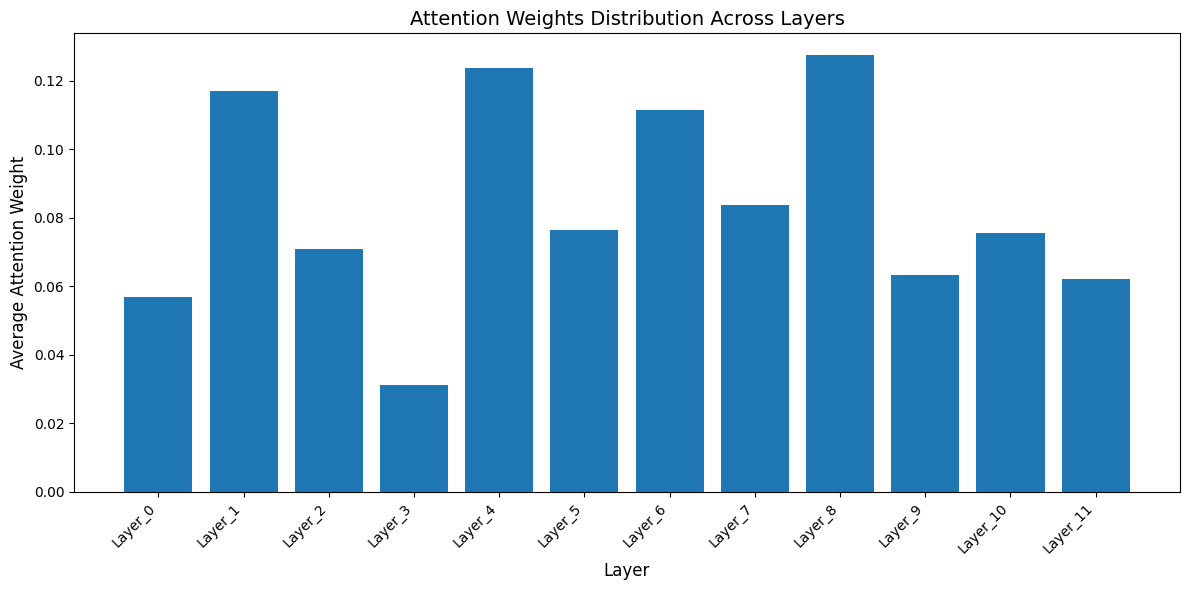

📊 注意力权重可视化结果已保存至 attn_weights.png


In [7]:
def visualize_attn_weights(attn_weights: torch.Tensor, layer_names: List[str], save_path: str = "attn_weights.png"):
    """
    可视化注意力权重的跨层分布 | 对应论文 Figure 3

    将 (batch, num_layers) 的注意力权重沿 batch 维取均值，
    绘制每层平均注意力权重的柱状图，直观展示模型"关注"哪些历史层。

    参数:
        attn_weights (torch.Tensor): 注意力权重张量，形状 (batch, num_layers)，
                                     每行之和为 1（由 softmax 保证）；dtype 通常为 float32。
        layer_names (List[str]):     层名称列表，长度必须等于 num_layers，
                                     如 ['Layer_0', 'Layer_1', ...]，用作 x 轴刻度标签。
        save_path (str):             可视化图片的保存路径，默认 "attn_weights.png"；
                                     图片格式由后缀名决定（如 .png/.pdf/.svg）。

    返回:
        None（副作用：将图表保存到 save_path 并在 notebook 中内联显示）
    """
    # 对 batch 维度求均值，得到跨样本的平均注意力权重；形状从 [batch, num_layers] 降为 [num_layers]
    avg_weights = attn_weights.mean(dim=0).cpu().numpy()  # numpy数组，形状 [num_layers]
    # 创建画布，宽12英寸、高6英寸，适配较多层数的横向展示
    plt.figure(figsize=(12, 6))  # 创建画布，宽 12 英寸、高 6 英寸
    # 绘制蓝色柱状图，x轴为层名称，y轴为平均权重值
    plt.bar(layer_names, avg_weights, color="#1f77b4")
    # 旋转x轴标签45°并右对齐，防止层名称重叠
    plt.xticks(rotation=45, ha="right")  # x 轴刻度旋转 45°，右对齐，防止层名重叠
    # 设置图表标题，字体大小14
    plt.title("Attention Weights Distribution Across Layers", fontsize=14)  # 设置图表标题，字号 14
    # 设置x轴标签
    plt.xlabel("Layer", fontsize=12)  # x 轴标签：层名称
    # 设置y轴标签
    plt.ylabel("Average Attention Weight", fontsize=12)  # y 轴标签：平均注意力权重
    plt.tight_layout()  # 自动调整子图参数，防止标签被截断
    # 保存图片到指定路径，分辨率300 dpi（适合论文/报告质量）
    plt.savefig(save_path, dpi=300)  # 保存高分辨率图片（300 dpi），格式由路径后缀决定
    plt.show()  # 在 notebook 中内联显示图表
    print(f"📊 注意力权重可视化结果已保存至 {save_path}")  # 提示保存路径

# 可视化使用示例（仅在直接运行脚本时执行，notebook中 __name__ == "__main__" 始终为真）
if __name__ == "__main__":
    # 模拟注意力权重：随机初始化，batch=8，共12层
    fake_attn_weights = torch.randn(8, 12)  # 模拟 (batch=8, num_layers=12) 的原始得分
    # 对每个样本做 softmax，模拟真实的归一化注意力权重；形状 [8, 12]
    fake_attn_weights = F.softmax(fake_attn_weights, dim=-1)  # softmax 归一化，每行权重之和为 1
    # 生成12个层的名称列表，如 ['Layer_0', ..., 'Layer_11']
    layer_names = [f"Layer_{i}" for i in range(12)]  # 构造层名列表 ["Layer_0", ..., "Layer_11"]
    # 调用可视化函数，绘制并保存注意力权重分布图
    visualize_attn_weights(fake_attn_weights, layer_names)  # 调用可视化函数，保存并展示注意力权重分布图